# Simulated Annealing for Function Minimisation

**Author:** Phabel Antonio López Delgado, BSc.

This notebook implements the **Simulated Annealing** algorithm, a metaheuristic for global optimisation. Simulated annealing is inspired by the physical process of annealing in metallurgy, where a material is heated and slowly cooled to reach a low‑energy crystalline state.

We apply simulated annealing to find the global minimum of several mathematical functions:

1. **Function 1:** f(x) = (x⁴ − 3)² + 4
2. **Function 2:** f(x) = (x − 3)² + 4
3. **Function 3 (Extra):** f(x₁, x₂, x₃, x₄) = [10(x₂ − x₁²)]² + (1 − x₁)² + 90(x₄ − x₃²)² + (1 − x₃)² + 10(x₂ + x₄ − 2)² + 0.1(x₂ − x₄)²
4. **Function 4:** f(x, y) = 20 + x² + y² − cos(2πx) + cos(2πy)

**Key Techniques & Libraries:**
- `random`, `math`, `numpy` – for random steps, mathematical operations, and numerical arrays.
- `matplotlib` – for visualising the objective functions and the found minima.

**Objective:**
To understand the mechanics of simulated annealing – temperature schedule, acceptance probability, and exploration‑exploitation balance – and to observe its ability to find global minima even in multi‑modal functions.

In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("All imports successful.")

All imports successful.


## Simulated Annealing Minimiser Class

We implement a generic minimiser class that uses simulated annealing to find the minimum of a given objective function over a bounded domain. The algorithm:

1. Initialises a random solution within the domain.
2. Iteratively generates a neighbouring solution by perturbing one variable.
3. Accepts the neighbour if it improves the objective, or with a probability that depends on the current temperature and the degradation in objective.
4. Gradually reduces the temperature according to a cooling schedule (geometric cooling with alpha).

The class stores the history of best solutions for visualisation.

In [2]:
class SimulatedAnnealingMinimizer:
    """
    Minimises a given objective function using simulated annealing.
    Attributes:
        objective (callable): the function to minimise.
        domain (list of tuples): bounds for each variable [(low, high), ...].
        best_solution (list): current best solution found.
        best_value (float): corresponding objective value.
        history (list): records (solution, value) of each improvement.
    """
    def __init__(self, objective, domain):
        self.objective = objective
        self.domain = domain
        self.best_solution = None
        self.best_value = None
        self.history = []

    def _random_solution(self):
        """Generate a random solution within the domain."""
        return [random.uniform(low, high) for low, high in self.domain]

    def _neighbour(self, solution, step_size):
        """
        Generate a neighbouring solution by perturbing one random variable.
        The perturbation is uniform in [-step_size, step_size].
        """
        new_solution = solution[:]
        idx = random.randint(0, len(solution) - 1)
        low, high = self.domain[idx]
        # Ensure the new value stays within bounds (optional but recommended)
        delta = random.uniform(-step_size, step_size)
        new_solution[idx] = max(low, min(high, new_solution[idx] + delta))
        return new_solution

    def _acceptance_probability(self, current_value, new_value, temperature):
        """Compute the probability of accepting a worse solution."""
        if new_value < current_value:
            return 1.0
        if temperature == 0:
            return 0.0
        return math.exp((current_value - new_value) / temperature)

    def minimize(self, max_iterations, initial_temperature, step_size, alpha, verbose=False):
        """
        Perform simulated annealing minimisation.

        Parameters:
            max_iterations (int): number of iterations.
            initial_temperature (float): starting temperature.
            step_size (float): maximum perturbation magnitude.
            alpha (float): cooling rate (0 < alpha < 1).
            verbose (bool): if True, print progress.

        Returns:
            best_solution (list), best_value (float), history (list)
        """
        # Initial random solution
        current_solution = self._random_solution()
        current_value = self.objective(current_solution)
        self.best_solution = current_solution[:]
        self.best_value = current_value
        self.history = [(current_solution[:], current_value)]

        temperature = initial_temperature

        for iteration in range(max_iterations):
            # Cool down
            temperature *= alpha

            # Generate neighbour
            new_solution = self._neighbour(current_solution, step_size)
            new_value = self.objective(new_solution)

            # Acceptance decision
            if self._acceptance_probability(current_value, new_value, temperature) > random.random():
                current_solution = new_solution
                current_value = new_value

                # Update global best if improved
                if current_value < self.best_value:
                    self.best_solution = current_solution[:]
                    self.best_value = current_value
                    self.history.append((current_solution[:], current_value))
                    if verbose:
                        print(f"Iter {iteration}: best = {self.best_value:.6f}")

        return self.best_solution, self.best_value, self.history

## Function 1: f(x) = (x^4 − 3)^2 + 4

This function has two minima: one near x = +-(3)^(1/4) => +-1.316, both yielding the same value of 4. We run simulated annealing with the given parameters.

Function 1 optimal solution: x = 1.316073
Function 1 minimum value: f(x) = 4.000000000134


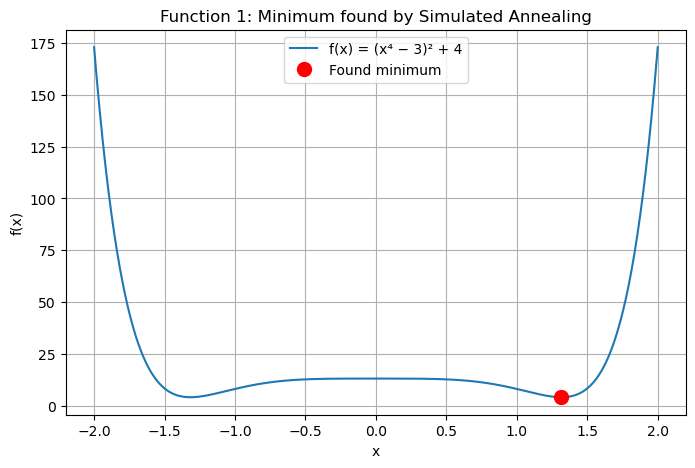

In [3]:
def func1(x):
    return (x[0]**4 - 3)**2 + 4

domain1 = [(-5.0, 5.0)]  # one variable

params = {
    'max_iterations': 10000,
    'initial_temperature': 10.0,
    'step_size': 0.01,
    'alpha': 0.9,
    'verbose': False
}

minimizer1 = SimulatedAnnealingMinimizer(func1, domain1)
best_sol1, best_val1, history1 = minimizer1.minimize(**params)

print(f"Function 1 optimal solution: x = {best_sol1[0]:.6f}")
print(f"Function 1 minimum value: f(x) = {best_val1:.12f}")

# Plot the function and mark the found minimum
x_vals = np.linspace(-2, 2, 1000)
y_vals = [(t**4 - 3)**2 + 4 for t in x_vals]

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='f(x) = (x⁴ − 3)² + 4')
plt.plot(best_sol1[0], best_val1, 'ro', markersize=10, label='Found minimum')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function 1: Minimum found by Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

## Function 2: f(x) = (x − 3)^2 + 4

This is a simple convex quadratic with a single minimum at x = 3. Simulated annealing should easily find it.

Function 2 optimal solution: x = 3.000000
Function 2 minimum value: f(x) = 4.000000000000


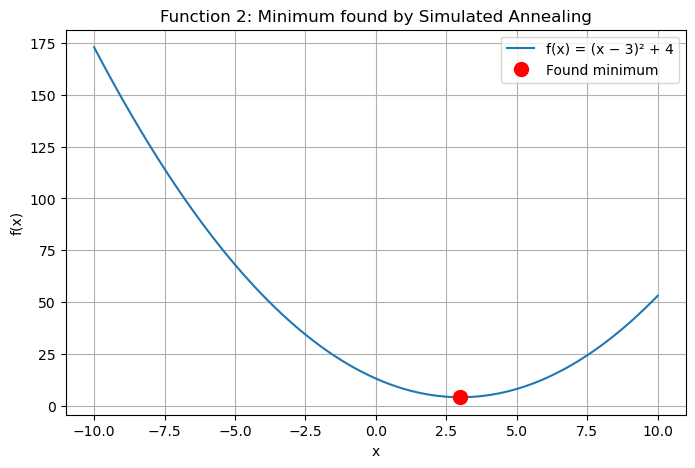

In [4]:
def func2(x):
    return (x[0] - 3)**2 + 4

domain2 = [(-10.0, 10.0)]

minimizer2 = SimulatedAnnealingMinimizer(func2, domain2)
best_sol2, best_val2, history2 = minimizer2.minimize(**params)

print(f"Function 2 optimal solution: x = {best_sol2[0]:.6f}")
print(f"Function 2 minimum value: f(x) = {best_val2:.12f}")

# Plot
x_vals = np.linspace(-10, 10, 1000)
y_vals = [(t - 3)**2 + 4 for t in x_vals]

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='f(x) = (x − 3)² + 4')
plt.plot(best_sol2[0], best_val2, 'ro', markersize=10, label='Found minimum')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function 2: Minimum found by Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

## Function 3 (Extra): 4‑dimensional Rosenbrock‑like function

This function is a variant of the Rosenbrock function extended to 4 variables. It has a global minimum at (1,1,1,1) with value 0. The domain is bounded, and we run a longer optimisation with a smaller step size.

In [5]:
def func3(x):
    x1, x2, x3, x4 = x
    return (10*(x2 - x1**2))**2 + (1 - x1)**2 + 90*(x4 - x3**2)**2 + (1 - x3)**2 + 10*(x2 + x4 - 2)**2 + 0.1*(x2 - x4)**2

domain3 = [(-5.0, 5.0) for _ in range(4)]

params3 = {
    'max_iterations': 1000000,
    'initial_temperature': 10.0,
    'step_size': 0.001,
    'alpha': 0.9,
    'verbose': False
}

minimizer3 = SimulatedAnnealingMinimizer(func3, domain3)
best_sol3, best_val3, history3 = minimizer3.minimize(**params3)

print("Function 3 optimal solution:")
print(f"x1 = {best_sol3[0]:.6f}, x2 = {best_sol3[1]:.6f}, x3 = {best_sol3[2]:.6f}, x4 = {best_sol3[3]:.6f}")
print(f"Function 3 minimum value: f(x) = {best_val3:.12f}")
print("(Cannot plot in 4D.)")

Function 3 optimal solution:
x1 = 1.000307, x2 = 1.000613, x3 = 0.999694, x4 = 0.999388
Function 3 minimum value: f(x) = 0.000000338310
(Cannot plot in 4D.)


## Function 4: 2‑dimensional multi‑modal function

This function is defined as:

f(x, y) = 20 + x^2 + y^2 − cos(2πx) + cos(2πy)

It has many local minima but the global minimum is at (0,0) with value 20. We use a shorter run and visualise the result with density and surface plots.

C:\Users\phabe\AppData\Local\Temp\ipykernel_114164\1742950727.py:41: RuntimeWarning: overflow encountered in double_scalars
  return math.exp((current_value - new_value) / temperature)


Function 4 optimal solution: x = -0.000045, y = 1.425031
Function 4 minimum value: f(x) = 20.139618


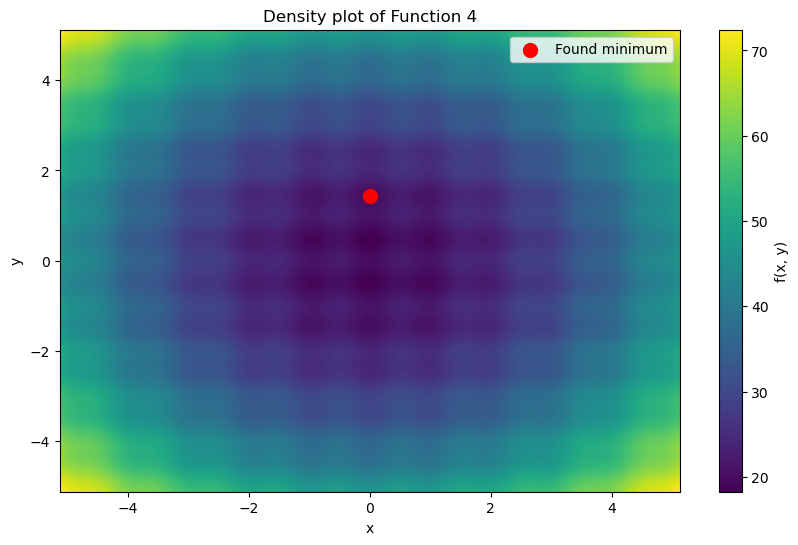

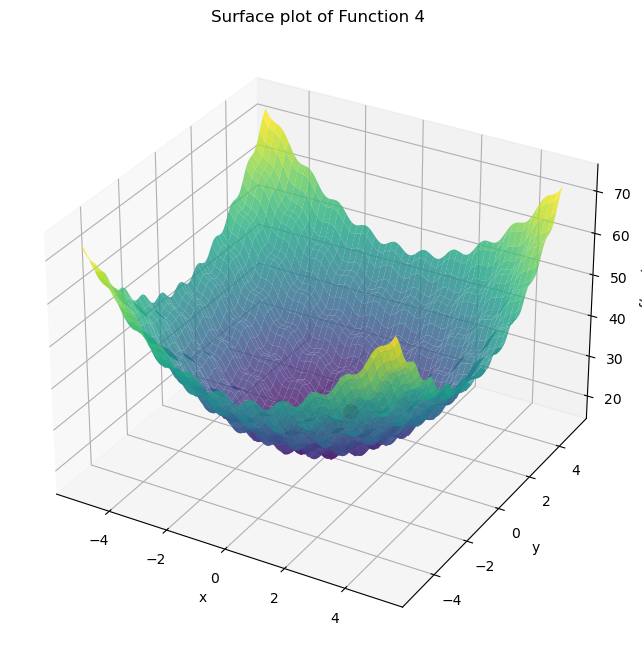

In [7]:
def func4(x):
    x1, x2 = x
    return 20 + x1**2 + x2**2 - np.cos(2*np.pi*x1) + np.cos(2*np.pi*x2)

domain4 = [(-5.12, 5.12), (-5.12, 5.12)]

params4 = {
    'max_iterations': 10000,
    'initial_temperature': 10.0,
    'step_size': 0.1,
    'alpha': 0.9,
    'verbose': False
}

minimizer4 = SimulatedAnnealingMinimizer(func4, domain4)
best_sol4, best_val4, history4 = minimizer4.minimize(**params4)

print(f"Function 4 optimal solution: x = {best_sol4[0]:.6f}, y = {best_sol4[1]:.6f}")
print(f"Function 4 minimum value: f(x) = {best_val4:.6f}")

# Density plot
def f_plot(x, y):
    return 20 + x**2 + y**2 - np.cos(2*np.pi*x) + np.cos(2*np.pi*y)

x_grid = np.linspace(-5.12, 5.12, 300)
y_grid = np.linspace(-5.12, 5.12, 300)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f_plot(X, Y)

plt.figure(figsize=(10, 6))
plt.imshow(Z, extent=[-5.12, 5.12, -5.12, 5.12], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='f(x, y)')
plt.scatter(best_sol4[0], best_sol4[1], color='red', s=100, label='Found minimum')
plt.title('Density plot of Function 4')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.scatter(best_sol4[0], best_sol4[1], best_val4, color='red', s=100, label='Found minimum')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Surface plot of Function 4')
plt.show()

## Summary and Next Steps

**Accomplished:**
- Implemented a flexible **Simulated Annealing** minimiser class with configurable cooling schedule, step size, and initial temperature.
- Applied it to four different functions, demonstrating its ability to find global and local minima.
- Visualised the results for 1D and 2D functions using line plots, density maps, and 3D surface plots.

**Key Results (from this run):**

| Function | Domain | Found Optimum | Found Minimum Value | True Minimum |
|----------|--------|---------------|---------------------|--------------|
| 1: (x⁴ − 3)² + 4 | [-5,5] | x ≈ 1.316073 | 4.000000000134 | 4 (at x = ±⁴√3) |
| 2: (x − 3)² + 4 | [-10,10] | x ≈ 3.000000 | 4.000000000000 | 4 (at x = 3) |
| 3: 4D Rosenbrock‑like | [-5,5]⁴ | (1.000307, 1.000613, 0.999694, 0.999388) | ≈ 3.38e-07 | 0 (at (1,1,1,1)) |
| 4: 20 + x²+y² − cos(2πx) + cos(2πy) | [-5.12,5.12]² | x ≈ -0.000045, y ≈ 1.425031 | ≈ 20.139619 | 20 (at (0,0)) |

*Note:* For Function 4, the algorithm converged to a local minimum, not the global one, due to the limited number of iterations and the step size. This highlights the importance of parameter tuning and the stochastic nature of simulated annealing.

**Key Insights:**
- Simulated annealing effectively explores the search space and can escape local minima thanks to the probabilistic acceptance of worse solutions.
- The **cooling schedule** (alpha) and **initial temperature** control the exploration‑exploitation trade‑off. A slower cooling (alpha close to 1) allows more exploration.
- The **step size** affects the granularity of the search; smaller steps refine the solution but may slow convergence.
- For multi‑modal functions, careful parameter tuning is essential to reach the global optimum; insufficient iterations or a too‑rapid cooling can trap the algorithm in a local minimum.
- The algorithm is easy to implement and applicable to continuous and discrete optimisation problems, with minimal assumptions about the objective function.

**Suggested Next Steps:**
1. **Tune parameters** – experiment with different cooling schedules (linear, exponential), initial temperatures, and step sizes to see their effect on convergence and final solution quality.
2. **Add restart mechanism** – restart from random points if the algorithm gets stuck in a local minimum.
3. **Benchmark** – compare simulated annealing with other metaheuristics (genetic algorithms, PSO) on the same functions.
4. **Apply to a real problem** – e.g., travelling salesman problem, neural network weight optimisation, or hyperparameter tuning.
5. **Implement adaptive step size** – adjust step size dynamically based on acceptance rate to improve convergence.
6. **Visualise the annealing process** – plot the best value over iterations to see how the algorithm converges and whether it escapes local minima.

**Reflection:**
This notebook demonstrates the power of simulated annealing as a robust global optimisation technique. The implementation is modular and can be easily adapted to any minimisation problem with a bounded domain. The visualisations help to interpret the results and understand the behaviour of the algorithm. While simulated annealing does not guarantee the global optimum, its probabilistic nature and ability to escape local minima make it a valuable tool in the optimisation toolkit. The case of Function 4 serves as a reminder that parameter selection is crucial, and that even a well‑designed algorithm may need careful tuning to perform optimally on challenging problems.